In [35]:
import kagglehub
from matplotlib.pyplot import plot_date

# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\hp\.cache\kagglehub\datasets\dylanjcastillo\7k-books-with-metadata\versions\3


In [36]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [37]:
import pandas as pd

# 1. Đọc dữ liệu từ 2 file
df1 = pd.read_csv("books.csv")
df2 = pd.read_csv("books_with_ratings.csv")

# 2. Đổi tên cột của file thứ 2 cho đồng bộ với cấu trúc file thứ 1
df2_renamed = df2.rename(columns={
    'ISBN13': 'isbn13',
    'ISBN': 'isbn10',
    'Book-Title': 'title',
    'Book-Author': 'authors',
    'Year-Of-Publication': 'published_year',
    'Image-URL-L': 'thumbnail',
    'description': 'description',
    'rating_mean': 'average_rating',
    'rating_count': 'ratings_count'
})

# 3. Gộp 2 file lại với nhau (nối đuôi nhau)
df_combined = pd.concat([df1, df2_renamed], ignore_index=True)

# 4. Xóa những cuốn sách bị trùng mã isbn13 (Giữ lại thông tin của cuốn xuất hiện đầu tiên)
df_combined = df_combined.drop_duplicates(subset=['isbn13'], keep='first')

# 5. Lưu kết quả ra file mới
df_combined.to_csv("books_merged.csv", index=False)

print(f"Gộp file thành công! Tổng số sách hiện tại: {len(df_combined)}")

Gộp file thành công! Tổng số sách hiện tại: 19798


In [38]:
books = pd.read_csv("books_merged.csv")

In [39]:
books

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,Publisher,rating_std,weighted_rating,implicit_count,total_readers
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,NaN,NaN,NaN,NaN,NaN
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,NaN,NaN,NaN,NaN,NaN
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,NaN,NaN,NaN,NaN,NaN
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,NaN,NaN,NaN,NaN,NaN
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19793,9781558172838,1558172831,A Lethal Vintage,NaN,Martin Sylvester,NaN,http://images.amazon.com/images/P/1558172831.0...,"William Warner is a suave, witty wine merchant...",1989.0,NaN,NaN,0.0,Pinnacle Books,NaN,7.69,2.0,2.0
19794,9780445407015,0445407018,For the Good of the State,NaN,Anthony Price,NaN,http://images.amazon.com/images/P/0445407018.0...,A maze of political infighting and espionage f...,1988.0,NaN,NaN,0.0,Warner Books,NaN,7.69,2.0,2.0
19795,9780440119500,0440119502,The Dreaming Pool,NaN,Paula Christopher,NaN,http://images.amazon.com/images/P/0440119502.0...,Eslin Hillary uses her psychic powers to searc...,1987.0,NaN,NaN,0.0,Dell Publishing Company,NaN,7.69,2.0,2.0
19796,9780671502683,0671502689,SMART WOMEN : A Story of Hope,NaN,Judy Blume,NaN,http://images.amazon.com/images/P/0671502689.0...,This tender and hilarious story of a divorced ...,1985.0,6.60,NaN,10.0,Pocket,2.63,6.96,31.0,41.0


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

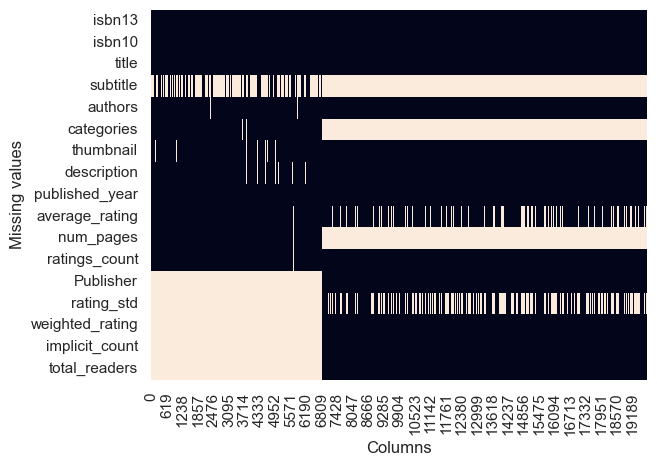

In [42]:
ax = plt.axes()
sns.heatmap(books.isna().transpose(), cbar=False, ax=ax)

plt.xlabel("Columns")
plt.ylabel("Missing values")

plt.show()

In [43]:
import numpy as np

books["missing_description"] = np.where(books["description"].isna(), 1, 0)
books["age_of_book"] = 2024 - books["published_year"]

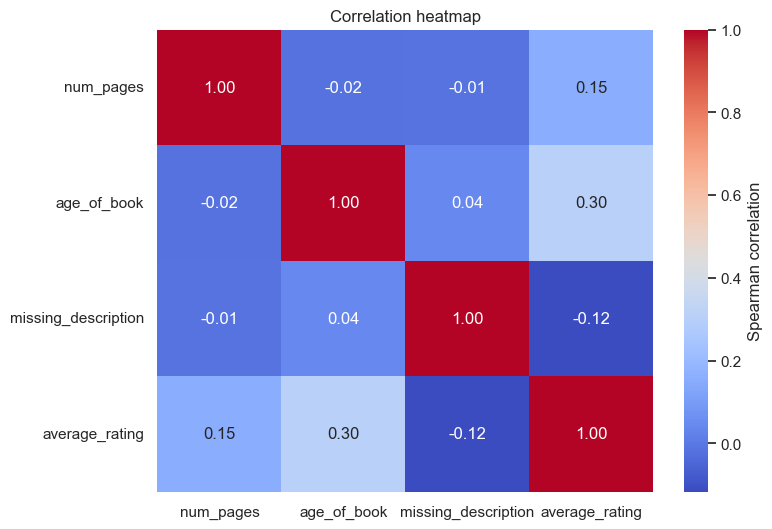

In [45]:
columns_of_interest = ["num_pages", "age_of_book", "missing_description", "average_rating"]

correlation_matrix = books[columns_of_interest].corr(method = "spearman")

sns.set_theme(style="white")
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                      cbar_kws={"label": "Spearman correlation"})
heatmap.set_title("Correlation heatmap")
plt.show()

In [46]:
# Chỉ bỏ những sách thiếu mô tả hoặc mô tả quá ngắn
book_missing = books[~(books["description"].isna())]

# Điền giá trị mặc định cho những cột bị thiếu (để không bị lỗi hiển thị sau này)
book_missing["num_pages"] = book_missing["num_pages"].fillna(0)
book_missing["average_rating"] = book_missing["average_rating"].fillna(0)
book_missing["published_year"] = book_missing["published_year"].fillna("Unknown")

In [47]:
book_missing

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,Publisher,rating_std,weighted_rating,implicit_count,total_readers,missing_description,age_of_book
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,NaN,NaN,NaN,NaN,NaN,0,20.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,NaN,NaN,NaN,NaN,NaN,0,24.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,NaN,NaN,NaN,NaN,NaN,0,42.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,NaN,NaN,NaN,NaN,NaN,0,31.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,NaN,NaN,NaN,NaN,NaN,0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19793,9781558172838,1558172831,A Lethal Vintage,NaN,Martin Sylvester,NaN,http://images.amazon.com/images/P/1558172831.0...,"William Warner is a suave, witty wine merchant...",1989.0,0.00,0.0,0.0,Pinnacle Books,NaN,7.69,2.0,2.0,0,35.0
19794,9780445407015,0445407018,For the Good of the State,NaN,Anthony Price,NaN,http://images.amazon.com/images/P/0445407018.0...,A maze of political infighting and espionage f...,1988.0,0.00,0.0,0.0,Warner Books,NaN,7.69,2.0,2.0,0,36.0
19795,9780440119500,0440119502,The Dreaming Pool,NaN,Paula Christopher,NaN,http://images.amazon.com/images/P/0440119502.0...,Eslin Hillary uses her psychic powers to searc...,1987.0,0.00,0.0,0.0,Dell Publishing Company,NaN,7.69,2.0,2.0,0,37.0
19796,9780671502683,0671502689,SMART WOMEN : A Story of Hope,NaN,Judy Blume,NaN,http://images.amazon.com/images/P/0671502689.0...,This tender and hilarious story of a divorced ...,1985.0,6.60,0.0,10.0,Pocket,2.63,6.96,31.0,41.0,0,39.0


In [48]:
book_missing["categories"].value_counts().reset_index().sort_values("count", ascending=False)

,categories,count
0,Fiction,2537
1,Juvenile Fiction,535
2,Biography & Autobiography,392
3,History,259
4,Literary Criticism,164
...,...,...
281,"Authors, Arab",1
280,"Nineteen ninety-eight, A.D.",1
279,Children of divorced parents,1
278,Animals,1


In [49]:
book_missing

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,Publisher,rating_std,weighted_rating,implicit_count,total_readers,missing_description,age_of_book
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,NaN,NaN,NaN,NaN,NaN,0,20.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,NaN,NaN,NaN,NaN,NaN,0,24.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,NaN,NaN,NaN,NaN,NaN,0,42.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,NaN,NaN,NaN,NaN,NaN,0,31.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,NaN,NaN,NaN,NaN,NaN,0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19793,9781558172838,1558172831,A Lethal Vintage,NaN,Martin Sylvester,NaN,http://images.amazon.com/images/P/1558172831.0...,"William Warner is a suave, witty wine merchant...",1989.0,0.00,0.0,0.0,Pinnacle Books,NaN,7.69,2.0,2.0,0,35.0
19794,9780445407015,0445407018,For the Good of the State,NaN,Anthony Price,NaN,http://images.amazon.com/images/P/0445407018.0...,A maze of political infighting and espionage f...,1988.0,0.00,0.0,0.0,Warner Books,NaN,7.69,2.0,2.0,0,36.0
19795,9780440119500,0440119502,The Dreaming Pool,NaN,Paula Christopher,NaN,http://images.amazon.com/images/P/0440119502.0...,Eslin Hillary uses her psychic powers to searc...,1987.0,0.00,0.0,0.0,Dell Publishing Company,NaN,7.69,2.0,2.0,0,37.0
19796,9780671502683,0671502689,SMART WOMEN : A Story of Hope,NaN,Judy Blume,NaN,http://images.amazon.com/images/P/0671502689.0...,This tender and hilarious story of a divorced ...,1985.0,6.60,0.0,10.0,Pocket,2.63,6.96,31.0,41.0,0,39.0


In [50]:
book_missing["words_in_description"] = book_missing["description"].str.split().str.len()

In [51]:
book_missing

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,Publisher,rating_std,weighted_rating,implicit_count,total_readers,missing_description,age_of_book,words_in_description
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,NaN,NaN,NaN,NaN,NaN,0,20.0,199
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,NaN,NaN,NaN,NaN,NaN,0,24.0,205
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,NaN,NaN,NaN,NaN,NaN,0,42.0,14
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,NaN,NaN,NaN,NaN,NaN,0,31.0,57
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,NaN,NaN,NaN,NaN,NaN,0,22.0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19793,9781558172838,1558172831,A Lethal Vintage,NaN,Martin Sylvester,NaN,http://images.amazon.com/images/P/1558172831.0...,"William Warner is a suave, witty wine merchant...",1989.0,0.00,0.0,0.0,Pinnacle Books,NaN,7.69,2.0,2.0,0,35.0,43
19794,9780445407015,0445407018,For the Good of the State,NaN,Anthony Price,NaN,http://images.amazon.com/images/P/0445407018.0...,A maze of political infighting and espionage f...,1988.0,0.00,0.0,0.0,Warner Books,NaN,7.69,2.0,2.0,0,36.0,28
19795,9780440119500,0440119502,The Dreaming Pool,NaN,Paula Christopher,NaN,http://images.amazon.com/images/P/0440119502.0...,Eslin Hillary uses her psychic powers to searc...,1987.0,0.00,0.0,0.0,Dell Publishing Company,NaN,7.69,2.0,2.0,0,37.0,22
19796,9780671502683,0671502689,SMART WOMEN : A Story of Hope,NaN,Judy Blume,NaN,http://images.amazon.com/images/P/0671502689.0...,This tender and hilarious story of a divorced ...,1985.0,6.60,0.0,10.0,Pocket,2.63,6.96,31.0,41.0,0,39.0,41


In [52]:
book_missing.loc[book_missing["words_in_description"].between(1, 4), "description"]

6                                           Donation.
11                                     Fantasy-roman.
748              Includes bibliographical references.
770                             Bound For Oregon (PB)
775                                No Marketing Blurb
812                                No Marketing Blurb
857                          First published in 1813.
944                         Edited by Maurice Hindle.
953                        DEFOE/ROBINSON CRUSOE (BC)
954                             Edited by John Carey.
962                         ALLEN/GETTING THINGS DONE
1054                            GILBERT/EAT PRAY LOVE
1056    "Graham Greene centennial, 1904-2004"--Cover.
1060                   STEINBECK/GRAPES OF WRATH (BC)
1346                                   Fantasy-roman.
1546                                      Winter 2003
1610                                      Winter 1999
1813                             National bestseller.
1981                        

In [54]:
book_missing.loc[book_missing["words_in_description"].between(5, 14), "description"]

2        Volume Two of Stephen Donaldson's acclaimed se...
38       Koko is Peter Straub's foray into the psycholo...
70       A matter of life and death - and the Throne of...
77                          Nonsense rhyming story. 4 yrs+
84       A study guide for the novel There's a Boy in t...
                               ...                        
19637    A collection of verses explaining what it mean...
19657    Recipes for Fresh Mex, Sol Food, Fajita's, and...
19661    Louisa May Alcott's classic story about young ...
19693    Clear and concise explanations of the developm...
19706    A guide to the festivals, traditions, and sacr...
Name: description, Length: 1015, dtype: object

In [55]:
book_missing.loc[book_missing["words_in_description"].between(15, 24), "description"]

10       One of Sidney Sheldon's most popular and bests...
32       Tells the story of three generations of Chines...
36       A magical and fantastic collection of early st...
57       A young drifter finds more than he bargained f...
68       A new 'The Doors of Perception' for the 21st c...
                               ...                        
19763    Relates the astounding and previously unknown ...
19764    Kent Family chronicles sees the family almost ...
19779    MAD LIBS, the World's Greatest Word Game, will...
19783    Revolves not around the Earth's imminent demis...
19795    Eslin Hillary uses her psychic powers to searc...
Name: description, Length: 3122, dtype: object

In [26]:
book_missing.loc[book_missing["words_in_description"].between(25, 34), "description"]

9        Kate Blackwell is an enigma and one of the mos...
14       Available in the U.S. for the first time, this...
20       It is 1937, and Charles Ashworth, a Canon to t...
21       Reissue of the author's most famous and well-l...
46       No one believes a little girl when she insists...
                               ...                        
13382    Bill Bryson meets Thor Heyerdahl in this hilar...
13387    The First Lady of the USSR recalls her childho...
13396    Guinevere is the daughter of a mighty pagan qu...
13397    The powerful debut of an unforgettable trilogy...
13399    A rollicking, riveting tour de force that does...
Name: description, Length: 2350, dtype: object

In [56]:
book_missing_25_words = book_missing[book_missing["words_in_description"] >= 25]

In [57]:
book_missing_25_words

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,Publisher,rating_std,weighted_rating,implicit_count,total_readers,missing_description,age_of_book,words_in_description
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,NaN,NaN,NaN,NaN,NaN,0,20.0,199
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,NaN,NaN,NaN,NaN,NaN,0,24.0,205
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,NaN,NaN,NaN,NaN,NaN,0,31.0,57
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,NaN,NaN,NaN,NaN,NaN,0,22.0,45
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,NaN,NaN,NaN,NaN,NaN,0,22.0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19792,9780886772215,0886772214,Trekmaster,NaN,James B. Johnson,NaN,http://images.amazon.com/images/P/0886772214.0...,"""The world of Bear Ridge, once colonized by Ol...",1987.0,0.00,0.0,0.0,New Amer Library,NaN,7.69,2.0,2.0,0,37.0,158
19793,9781558172838,1558172831,A Lethal Vintage,NaN,Martin Sylvester,NaN,http://images.amazon.com/images/P/1558172831.0...,"William Warner is a suave, witty wine merchant...",1989.0,0.00,0.0,0.0,Pinnacle Books,NaN,7.69,2.0,2.0,0,35.0,43
19794,9780445407015,0445407018,For the Good of the State,NaN,Anthony Price,NaN,http://images.amazon.com/images/P/0445407018.0...,A maze of political infighting and espionage f...,1988.0,0.00,0.0,0.0,Warner Books,NaN,7.69,2.0,2.0,0,36.0,28
19796,9780671502683,0671502689,SMART WOMEN : A Story of Hope,NaN,Judy Blume,NaN,http://images.amazon.com/images/P/0671502689.0...,This tender and hilarious story of a divorced ...,1985.0,6.60,0.0,10.0,Pocket,2.63,6.96,31.0,41.0,0,39.0,41


In [58]:
book_missing_25_words["title_and_subtitle"] = (
    np.where(book_missing_25_words["subtitle"].isna(), book_missing_25_words["title"],
             book_missing_25_words[["title", "subtitle"]].astype(str).agg(": ".join, axis=1))
)

In [59]:
book_missing_25_words

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,...,ratings_count,Publisher,rating_std,weighted_rating,implicit_count,total_readers,missing_description,age_of_book,words_in_description,title_and_subtitle
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,...,361.0,NaN,NaN,NaN,NaN,NaN,0,20.0,199,Gilead
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,...,5164.0,NaN,NaN,NaN,NaN,NaN,0,24.0,205,Spider's Web: A Novel
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,...,29532.0,NaN,NaN,NaN,NaN,NaN,0,31.0,57,Rage of angels
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,...,33684.0,NaN,NaN,NaN,NaN,NaN,0,22.0,45,The Four Loves
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,...,37569.0,NaN,NaN,NaN,NaN,NaN,0,22.0,75,The Problem of Pain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19792,9780886772215,0886772214,Trekmaster,NaN,James B. Johnson,NaN,http://images.amazon.com/images/P/0886772214.0...,"""The world of Bear Ridge, once colonized by Ol...",1987.0,0.00,...,0.0,New Amer Library,NaN,7.69,2.0,2.0,0,37.0,158,Trekmaster
19793,9781558172838,1558172831,A Lethal Vintage,NaN,Martin Sylvester,NaN,http://images.amazon.com/images/P/1558172831.0...,"William Warner is a suave, witty wine merchant...",1989.0,0.00,...,0.0,Pinnacle Books,NaN,7.69,2.0,2.0,0,35.0,43,A Lethal Vintage
19794,9780445407015,0445407018,For the Good of the State,NaN,Anthony Price,NaN,http://images.amazon.com/images/P/0445407018.0...,A maze of political infighting and espionage f...,1988.0,0.00,...,0.0,Warner Books,NaN,7.69,2.0,2.0,0,36.0,28,For the Good of the State
19796,9780671502683,0671502689,SMART WOMEN : A Story of Hope,NaN,Judy Blume,NaN,http://images.amazon.com/images/P/0671502689.0...,This tender and hilarious story of a divorced ...,1985.0,6.60,...,10.0,Pocket,2.63,6.96,31.0,41.0,0,39.0,41,SMART WOMEN : A Story of Hope


In [62]:
book_missing_25_words["tagged_description"] = book_missing_25_words[["isbn13", "description"]].astype(str).agg(" ".join, axis=1)

In [63]:
book_missing_25_words

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,...,Publisher,rating_std,weighted_rating,implicit_count,total_readers,missing_description,age_of_book,words_in_description,title_and_subtitle,tagged_description
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,...,NaN,NaN,NaN,NaN,NaN,0,20.0,199,Gilead,9780002005883 A NOVEL THAT READERS and critics...
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,...,NaN,NaN,NaN,NaN,NaN,0,24.0,205,Spider's Web: A Novel,9780002261982 A new 'Christie for Christmas' -...
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,...,NaN,NaN,NaN,NaN,NaN,0,31.0,57,Rage of angels,"9780006178736 A memorable, mesmerizing heroine..."
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,...,NaN,NaN,NaN,NaN,NaN,0,22.0,45,The Four Loves,9780006280897 Lewis' work on the nature of lov...
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,...,NaN,NaN,NaN,NaN,NaN,0,22.0,75,The Problem of Pain,"9780006280934 ""In The Problem of Pain, C.S. Le..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19792,9780886772215,0886772214,Trekmaster,NaN,James B. Johnson,NaN,http://images.amazon.com/images/P/0886772214.0...,"""The world of Bear Ridge, once colonized by Ol...",1987.0,0.00,...,New Amer Library,NaN,7.69,2.0,2.0,0,37.0,158,Trekmaster,"9780886772215 ""The world of Bear Ridge, once c..."
19793,9781558172838,1558172831,A Lethal Vintage,NaN,Martin Sylvester,NaN,http://images.amazon.com/images/P/1558172831.0...,"William Warner is a suave, witty wine merchant...",1989.0,0.00,...,Pinnacle Books,NaN,7.69,2.0,2.0,0,35.0,43,A Lethal Vintage,"9781558172838 William Warner is a suave, witty..."
19794,9780445407015,0445407018,For the Good of the State,NaN,Anthony Price,NaN,http://images.amazon.com/images/P/0445407018.0...,A maze of political infighting and espionage f...,1988.0,0.00,...,Warner Books,NaN,7.69,2.0,2.0,0,36.0,28,For the Good of the State,9780445407015 A maze of political infighting a...
19796,9780671502683,0671502689,SMART WOMEN : A Story of Hope,NaN,Judy Blume,NaN,http://images.amazon.com/images/P/0671502689.0...,This tender and hilarious story of a divorced ...,1985.0,6.60,...,Pocket,2.63,6.96,31.0,41.0,0,39.0,41,SMART WOMEN : A Story of Hope,9780671502683 This tender and hilarious story ...


In [64]:
(
    book_missing_25_words
    .drop(["subtitle", "missing_description", "age_of_book", "words_in_description"], axis=1)
    .to_csv("books_cleaned.csv", index = False)
)